# K means clustering

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Make plots a little bigger and results reproducible
plt.rcParams['figure.figsize'] = (6, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded successfully!")


Libraries loaded successfully!


## Create a Simple 2D Dataset

Shape of X: (300, 2)


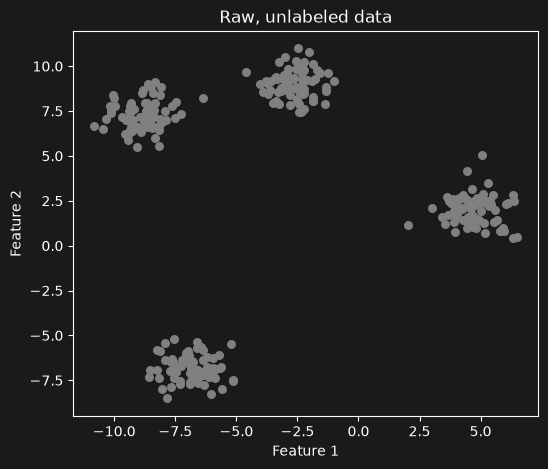

In [4]:
# Generate synthetic data: 300 points, 4 natural groups
X, y_true = make_blobs(
 n_samples=300,
 centers=4,
 cluster_std=0.80,
 random_state=RANDOM_STATE
)
print("Shape of X:", X.shape) # 300 rows (points), 2 columns (x, y coordinates)
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray')
plt.title("Raw, unlabeled data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Fit a K-Means Model

In [44]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X)
# The cluster label assigned to each point
labels = kmeans.labels_
# The final centroid (center) locations
centroids = kmeans.cluster_centers_
print("First 10 cluster assignments:", labels[:10])
print("\nCentroid coordinates:\n", centroids)

First 10 cluster assignments: [3 3 0 1 3 1 2 1 0 2]

Centroid coordinates:
 [[-2.63715917  8.98563949]
 [-6.84180708 -6.84038791]
 [ 4.70253968  2.02807134]
 [-8.83330596  7.21790214]]


## Visualize the Clusters

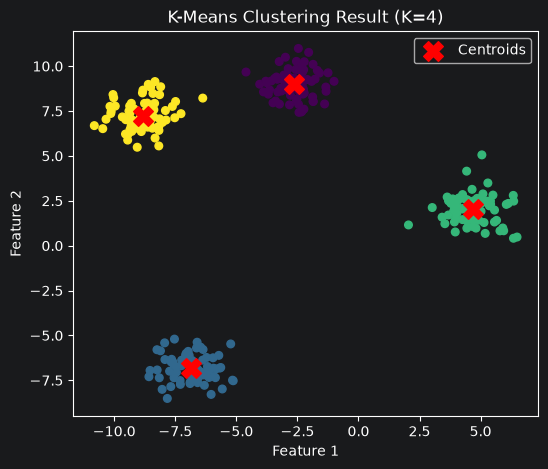

In [45]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title(f"K-Means Clustering Result (K={K})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## How Do We Choose K? The Elbow Method

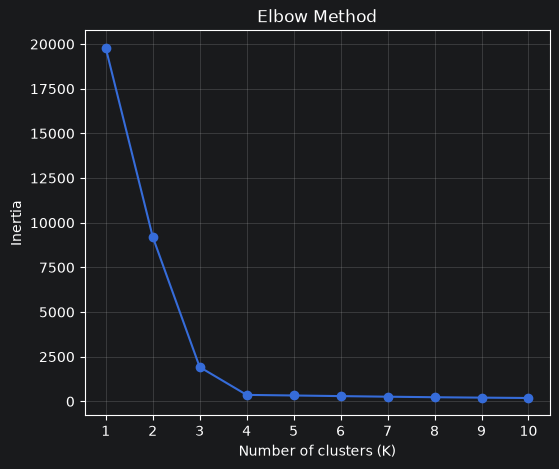

In [8]:
inertias = []
K_range = range(1, 11)
for k in K_range:
 km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
 km.fit(X)
 inertias.append(km.inertia_)
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.show()

## A Second Way to Choose K: Silhouette Score

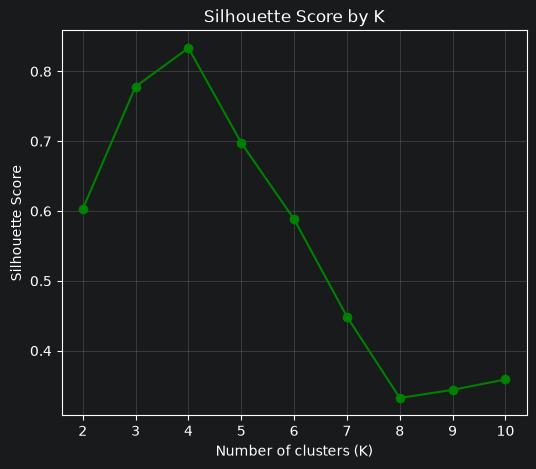

K with the highest silhouette score: 4


In [9]:
sil_scores = []
K_range_sil = range(2, 11) # silhouette score is undefined for K=1
for k in K_range_sil:
 km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
 km.fit(X)
 score = silhouette_score(X, km.labels_)
 sil_scores.append(score)
plt.plot(list(K_range_sil), sil_scores, marker='o', color='green')
plt.title("Silhouette Score by K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_range_sil))
plt.grid(alpha=0.3)
plt.show()
best_k = list(K_range_sil)[int(np.argmax(sil_scores))]
print(f"K with the highest silhouette score: {best_k}")

##  Guided Exercise: Customer Segmentation

In [16]:
import pandas as pd
# Synthetic customer data: [Annual Income (k$), Spending Score (1-100)]
customer_data = pd.DataFrame({
 'annual_income_k': [15, 16, 17, 18, 19, 20, 26, 27, 28, 29,
 60, 62, 64, 66, 68, 70, 85, 87, 90, 92,
 95, 97, 99, 101, 103, 40, 42, 44, 46, 48],
 'spending_score': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72,
 49, 55, 42, 52, 47, 50, 79, 20, 82, 15,
 75, 18, 78, 22, 80, 55, 60, 45, 58, 52]
})
customer_data.head()

,annual_income_k,spending_score
0,15,39
1,16,81
2,17,6
3,18,77
4,19,40


In [30]:
# TODO 1: Convert the DataFrame into a NumPy array called X_customers
# Hint: use customer_data.values
X_customers = customer_data.values

<class 'numpy.ndarray'>


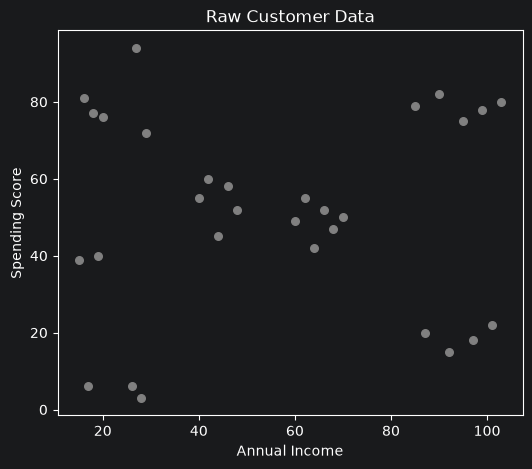

In [34]:
# TODO 2: Plot the raw (unclustered) customer data as a scatter plot.
# X-axis: Annual Income, Y-axis: Spending Score

plt.scatter(customer_data['annual_income_k'], customer_data['spending_score'],
            color='gray', s=30)

plt.title("Raw Customer Data")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [52]:
# TODO 3: Fit a KMeans model on X_customers with K=5 clusters.
# Store the fitted model in a variable called `customer_kmeans`,
# and the cluster labels in a variable called `customer_labels`

customer_kmeans = KMeans(n_clusters=15, random_state=RANDOM_STATE, n_init=10)
customer_kmeans.fit(X_customers)

customer_labels = customer_kmeans.labels_
print("Cluster labels for each customer:", customer_labels)

Cluster labels for each customer: [ 6 14  3 14  6 14  8  7  8  4  5  5 10  5 10 10 13  2 13  2  1 12 11 12
 11  0  0  9  0  9]


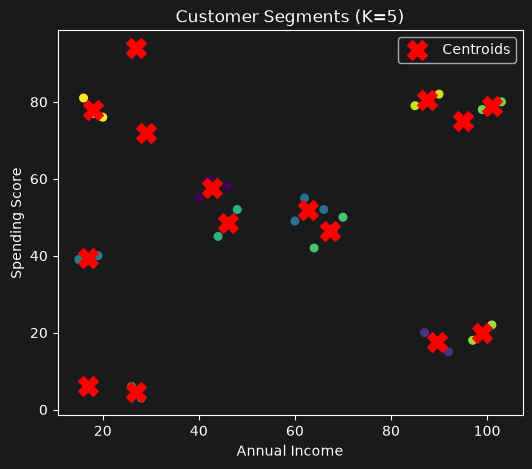

In [53]:
# TODO 4: Visualize the resulting clusters and centroids

customer_centroids = customer_kmeans.cluster_centers_

plt.scatter(
    X_customers[:, 0],
    X_customers[:, 1],
    c=customer_labels,
    cmap='viridis',
    s=30
)

plt.scatter(
    customer_centroids[:, 0],
    customer_centroids[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("Customer Segments (K=5)")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

 ## (Optional / Bonus) Implement K-Means From Scratch

If you want a deeper understanding, try implementing the core loop of K-Means yourself using only NumPy — no scikit-learn .
This mirrors the 5 steps described in Section 1.


Converged after 3 iterations


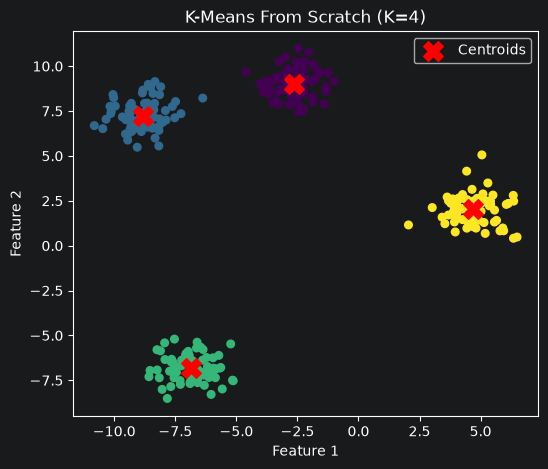

In [37]:
def my_kmeans(X, k, n_iters=100, random_state=42):
    rng = np.random.default_rng(random_state)

    # Step 2: Initialize centroids by picking k random data points
    initial_idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[initial_idx].copy()

    for iteration in range(n_iters):

        # Step 3: Assign each point to its nearest centroid
        distances = np.linalg.norm(
            X[:, None, :] - centroids[None, :, :],
            axis=2
        )
        labels = np.argmin(distances, axis=1)

        # Step 4: Update each centroid to the mean of its assigned points
        new_centroids = np.array([
            X[labels == i].mean(axis=0)
            if np.any(labels == i)
            else centroids[i]
            for i in range(k)
        ])

        # Step 5: Check for convergence
        if np.allclose(new_centroids, centroids, atol=1e-6):
            print(f"Converged after {iteration + 1} iterations")
            break

        centroids = new_centroids

    return labels, centroids


# Run K-Means from scratch on the blob dataset
my_labels, my_centroids = my_kmeans(X, k=4)

# Visualize results
plt.scatter(X[:, 0], X[:, 1], c=my_labels, cmap='viridis', s=30)
plt.scatter(
    my_centroids[:, 0],
    my_centroids[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("K-Means From Scratch (K=4)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()